In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_parquet("data/flights_economy_1gb")

In [4]:
data.columns

Index(['legId', 'searchDate', 'flightDate', 'startingAirport',
       'destinationAirport', 'numDaysToFlight', 'numLayovers',
       'layoverDurationMinutes', 'seatsRemaining', 'travelDuration',
       'totalTravelDistance', 'elapsedDays', 'isBasicEconomy', 'isRefundable',
       'isNonStop', 'baseFare', 'totalFare', 'segmentsDepartureTime',
       'segmentsArrivalTime', 'segmentsArrivalAirportCode',
       'segmentsDepartureAirportCode', 'segmentsAirlineName',
       'segmentsAirlineCode', 'segmentsAircraft', 'segmentsDurationInMinutes',
       'segmentsDistance', 'segmentsCabinCode'],
      dtype='str')

In [5]:
data['flightDate'] = pd.to_datetime(data['flightDate'])

In [6]:
data['flight_day'] = data['flightDate'].dt.day_name()

In [7]:
data['is_weekend'] = data['flightDate'].dt.dayofweek >= 5

306.72
348.6


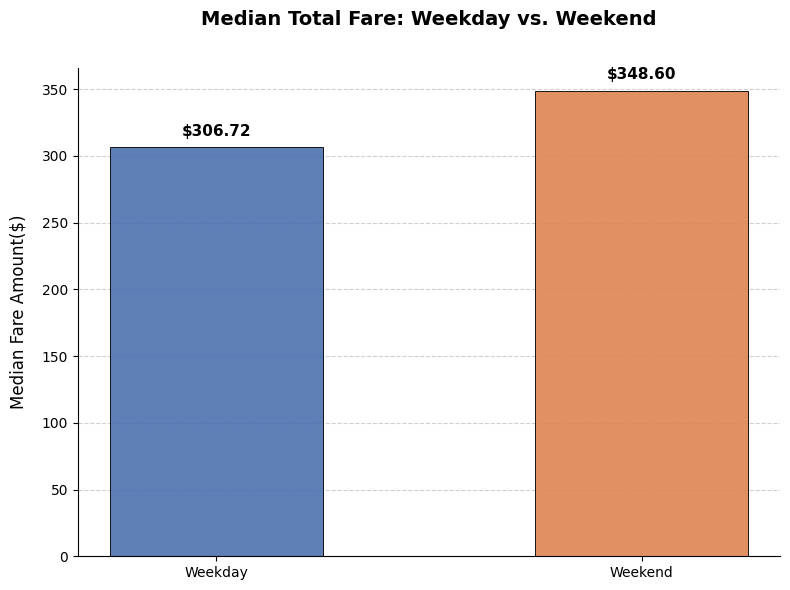

In [16]:
weekday_median = data[(data.is_weekend == False) & (data.totalFare < 2500)].totalFare.median()
weekend_median = data[(data.is_weekend == True)  & (data.totalFare < 2500)].totalFare.median()
print(weekday_median)
print(weekend_median)

# 1. Set up the figure with a better size
fig, ax = plt.subplots(figsize=(8, 6))

# Define your data and aesthetics
categories = ["Weekday", "Weekend"]
medians = [weekday_median, weekend_median]
colors = ['#4C72B0', '#DD8452']  # A clean, modern blue and orange

# 2. Create the bar chart
bars = ax.bar(categories, medians, color=colors, width=0.5, 
              edgecolor='black', linewidth=0.7, alpha=0.9)

# 3. Add titles and axis labels
ax.set_title("Median Total Fare: Weekday vs. Weekend\n", 
             fontsize=14, fontweight='bold', pad=15)
# ax.set_xlabel("Day Type", fontsize=12, labelpad=10)
ax.set_ylabel("Median Fare Amount($)", fontsize=12, labelpad=10)

# 4. Add data labels directly on top of the bars
for bar in bars:
    height = bar.get_height()
    # Format the text (adds a currency symbol and rounds to 2 decimals if needed)
    ax.text(bar.get_x() + bar.get_width() / 2, height + (height * 0.02),
            f'${height:,.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Clean up the background and borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6) # Subtle horizontal gridlines
ax.set_axisbelow(True) # Ensure gridlines stay behind the bars

# 6. Render
plt.tight_layout()
plt.savefig("weekday_vs_weekend_fare.png", dpi=300)
plt.show()

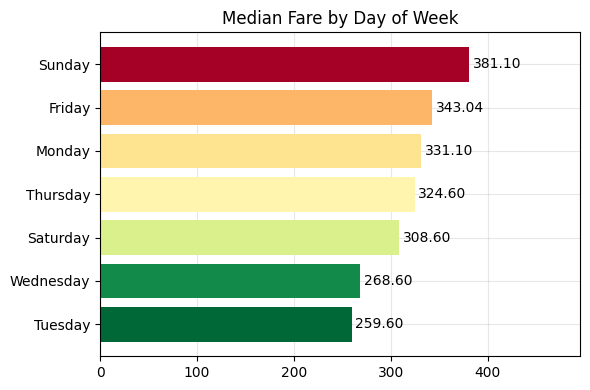

In [10]:
import matplotlib.pyplot as plt
import numpy as np

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
medians = []

# Compute medians
for day in days:
    day_median = data[data.flight_day == day].totalFare.median()
    medians.append(day_median)

# Sort once (not inside loop)
sorted_pairs = sorted(zip(days, medians), key=lambda x: x[1], reverse=True)
sorted_days, sorted_medians = zip(*sorted_pairs)

values = np.array(sorted_medians)

# RYG color mapping
norm = plt.Normalize(values.min(), values.max())
colors = plt.cm.RdYlGn_r(norm(values))  # red → yellow → green

# Plot
plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_axisbelow(True)

plt.grid(True, alpha=0.3, zorder=0)
plt.barh(sorted_days, values, color=colors, zorder=2)

ax.invert_yaxis()

# Labels on bars
offset = max(values) * 0.01
for i, value in enumerate(values):
    plt.text(value + offset, i, f"{value:.2f}", va="center")

plt.xlim(0, max(values) * 1.3)
plt.title("Median Fare by Day of Week")
plt.tight_layout()
plt.savefig("median_fare_daywise.png", dpi=300)
plt.show()